!pip install seaborn

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [14]:
df0 = pd.read_csv('all_v2.csv')

df0.head()

,price,date,time,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,20:00:21,59.806,30.376,2661,1,8,10,3,82.600,10.800,1
1,8650000,2018-02-27,12:04:54,55.684,37.297,81,3,5,24,2,69.100,12.000,1
2,4000000,2018-02-28,15:44:00,56.295,44.062,2871,1,5,9,3,66.000,10.000,1
3,1850000,2018-03-01,11:24:52,44.996,39.075,2843,4,12,16,2,38.000,5.000,11
4,5450000,2018-03-01,17:42:43,55.919,37.985,81,3,13,14,2,60.000,10.000,1


In [15]:
df0.shape

(5477006, 13)

Препроцессинг

In [16]:
df0.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   price          5477006 non-null  int64  
 1   date           5477006 non-null  object 
 2   time           5477006 non-null  object 
 3   geo_lat        5477006 non-null  float64
 4   geo_lon        5477006 non-null  float64
 5   region         5477006 non-null  int64  
 6   building_type  5477006 non-null  int64  
 7   level          5477006 non-null  int64  
 8   levels         5477006 non-null  int64  
 9   rooms          5477006 non-null  int64  
 10  area           5477006 non-null  float64
 11  kitchen_area   5477006 non-null  float64
 12  object_type    5477006 non-null  int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 543.2+ MB


In [17]:
pd.set_option('display.float_format', lambda x: '%.3f' % x) #чтобы были читаемы вещественные числа
df0.describe()

,price,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type
count,5477006.000,5477006.000,5477006.000,5477006.000,5477006.000,5477006.000,5477006.000,5477006.000,5477006.000,5477006.000,5477006.000
mean,4422029.023,54.038,53.244,4307.141,1.949,6.215,11.399,1.726,53.918,10.628,3.945
std,21507519.155,4.623,20.748,3308.050,1.039,4.957,6.536,1.082,33.353,9.792,4.558
min,-2144967296.000,41.459,19.890,3.000,0.000,1.000,1.000,-2.000,0.070,0.010,1.000
25%,1950000.000,53.378,37.778,2661.000,1.000,2.000,5.000,1.000,38.000,7.000,1.000
50%,2990000.000,55.171,43.068,2922.000,2.000,5.000,10.000,2.000,48.020,9.700,1.000
75%,4802000.000,56.226,65.649,6171.000,3.000,9.000,16.000,2.000,63.130,12.700,11.000
max,2147483647.000,71.980,162.536,61888.000,5.000,39.000,39.000,10.000,7856.000,9999.000,11.000


In [15]:
for i in df0.columns:
    print(i)
    print(df0[i].unique())

price
[ 6050000  8650000  4000000 ... 12503160 11831910 13316200]
date
['2018-02-19' '2018-02-27' '2018-02-28' ... '2021-04-29' '2021-04-30'
 '2021-05-01']
time
['20:00:21' '12:04:54' '15:44:00' ... '01:29:35' '01:31:09' '00:53:45']
geo_lat
[59.8058084 55.683807  56.29525   ... 59.9639084 43.00221   55.808892 ]
geo_lon
[30.376141  37.297405  44.061637  ... 30.2021802 30.3518695 47.45885  ]
region
[ 2661    81  2871  2843     3  3106  2922  2900  2722  6171  3230  4417
  5282  5368  3446  5520  6817  9579  2604  1010  9648  7793 13919  2860
  3019  4982  5241  3870  3991  2359  9654  2072  8090  4007 11171 10160
  7873  2594  8509 11416 11991  2880  5178 13913  6309  5952  6543  2328
  5993  2484 13098  4240  5789  1901 14880 10201  1491  2885  5794  2528
  4374  4695  5143  6937  2806 14368  5736  7121  4086   821 10582  7896
  8640  5703  8894  4249  3153  4189  2814  7929 16705    69  4963 61888]
building_type
[1 3 4 2 5 0]
level
[ 8  5 12 13  4  1  2  9 10 25  7  6 16 17 14 11  3 18

Проверка на пропущенные значения и дубликаты

Из данных df0.info (выше) заметим, что пропущенных значений во всем датасете нет. Проверим на NaN - значения:

In [18]:
df0.isna().sum()

price            0
date             0
time             0
geo_lat          0
geo_lon          0
region           0
building_type    0
level            0
levels           0
rooms            0
area             0
kitchen_area     0
object_type      0
dtype: int64

Значений NaN в наборе так же нет.

Проверка датасета на наличие полных дубликатов строк:

In [19]:
df0.duplicated().sum()

np.int64(1523)

Удаляем все дубликаты из датасета

In [20]:
df = df0.drop_duplicates()

df.shape

(5475483, 13)

Проведем очистку данных:¶
1. Удалим столбец time, так как это ненужная информация для модели

2. Поменяем все значения 11 в столбце object_type на 2

3. Меняем все отрицательные значения в столбце rooms на противоположные

4. Берем модуль от цены (стобец price), так как отрицательных цен не бывает, так же ограничеваем диапозон значений, чтобы избавится от выбросов

5. Если значения этажей в доме больше, чем этаж квартиры, то меняем их местами (так как это скорее просто ошибка парсинга), так же совмещаем два столбца (level и levels) в один level_to_levels, в котором будет хранится их отношение

6. Меняем формат представления даты - оставляем только год публикации объявнения

7. Ставим ограничение на area, kitchen_area чтобы избавится от выбросов

8. Считаем среднюю площадь комнаты в квартире - создаем столбец area_to_roms

In [21]:
df = df.drop('time', axis=1)

In [22]:
if 'time' in df.columns:
    df.drop('time', axis=1, inplace=True)

In [23]:
df["object_type"] = df["object_type"].apply(lambda x: 2 if x == 11 else x)

In [24]:
df['rooms'] = df["rooms"].apply(lambda x: 0 if x < 0 else x)

In [25]:
df["price"] = df["price"].abs()

min_price = 800000
max_price = 50000000

df = df[(df["price"] <= max_price) & (df["price"] >= min_price)]

In [26]:
print(df)

            price        date  geo_lat  geo_lon  region  building_type  level  \
0         6050000  2018-02-19   59.806   30.376    2661              1      8   
1         8650000  2018-02-27   55.684   37.297      81              3      5   
2         4000000  2018-02-28   56.295   44.062    2871              1      5   
3         1850000  2018-03-01   44.996   39.075    2843              4     12   
4         5450000  2018-03-01   55.919   37.985      81              3     13   
...           ...         ...      ...      ...     ...            ...    ...   
5477001  19739760  2021-05-01   55.805   37.751       3              1      8   
5477002  12503160  2021-05-01   55.841   37.490       3              2     17   
5477003   8800000  2021-05-01   56.284   44.075    2871              2      4   
5477004  11831910  2021-05-01   55.805   37.751       3              1      8   
5477005  13316200  2021-05-01   55.860   37.540       3              2     10   

         levels  rooms   ar

In [27]:
df.loc[df["level"] > df["levels"], "level"] = df["levels"]

df['level_to_levels'] = df['level'] / df['levels']

In [28]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
#df['day'] = df['date'].dt.day

df = df.drop(['date'], axis = 1)

In [29]:
min_area = 10
max_area = 150

min_kitchen_area = 6
max_kitchen_area = 40

df = df[(df["area"] <= max_area) & (df["area"] >= min_area)]
df = df[(df["kitchen_area"] <= max_kitchen_area) & (df["kitchen_area"] >= min_kitchen_area)]

In [30]:
df['area_to_rooms'] = (df['area'] / df['rooms'])
df.head()

,price,geo_lat,geo_lon,region,building_type,level,levels,rooms,area,kitchen_area,object_type,level_to_levels,year,month,area_to_rooms
0,6050000,59.806,30.376,2661,1,8,10,3,82.600,10.800,1,0.800,2018,2,27.533
1,8650000,55.684,37.297,81,3,5,24,2,69.100,12.000,1,0.208,2018,2,34.550
2,4000000,56.295,44.062,2871,1,5,9,3,66.000,10.000,1,0.556,2018,2,22.000
4,5450000,55.919,37.985,81,3,13,14,2,60.000,10.000,1,0.929,2018,3,30.000
5,3300000,55.908,37.726,81,1,4,5,1,32.000,6.000,1,0.800,2018,3,32.000


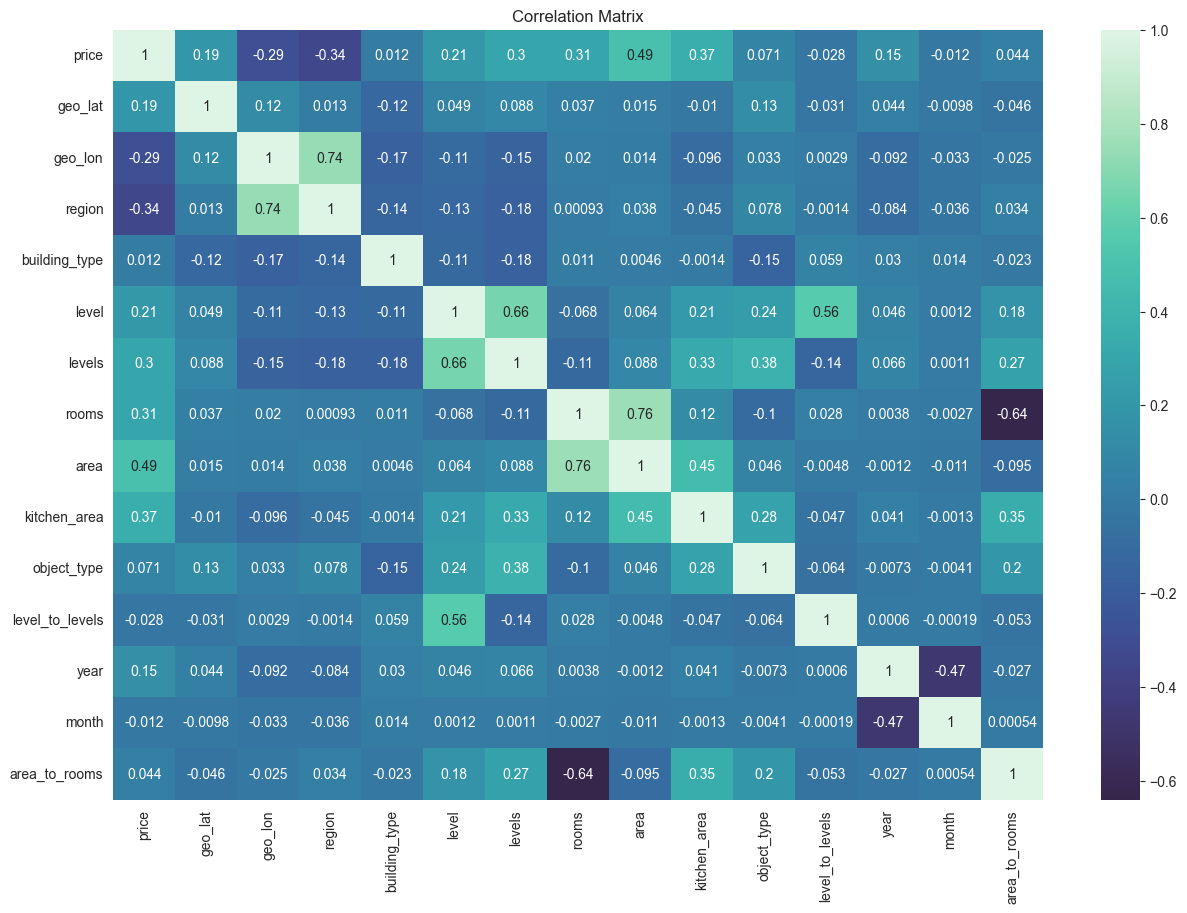

In [31]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), center=0, cmap='mako', annot=True)
plt.title('Correlation Matrix')
plt.show()

После анализа матрицы корреляции, заметим, что значимых зависимостей (мультиколлениарности) переменных нет, следовательно можно преступать к построению модели

Но для начала заметим, что регионы в датасете представлены в числовом виде, причем не общепринятом (это не код региона и не почтовый индекс)

Поэтому создадим еще один столбец - region_name, где будут хранится именно географические названия регионов

In [32]:
region_name = {
    '2661': 'Санкт-Петербург',
    '3446': 'Ленинградская область', 
    '3': 'Москва',
    '81': 'Московская область',
    '2843': 'Краснодарский край',
    '2871': 'Нижегородская область',
    '3230': 'Ростовская область',
    '3106': 'Самарская область',
    '2922': 'Республика Татарстан',
    '2900': 'Ставропольский край',
    '2722': 'Республика Башкортостан',
    '6171': 'Свердловская область', 
    '4417': 'Республика Коми', 
    '5282': 'Челябинская область', 
    '5368': 'Иркутская область', 
    '5520': 'Пермский край', 
    '6817': 'Алтайский край',
    '9579': 'Республика Бурятия',
    '2604': 'Ярославская область',
    '1010': 'Удмуртская Республика',
    '7793': 'Псковская область',
    '13919': 'Республика Северная Осетия — Алания',
    '2860': 'Кемеровская область',
    '3019': 'Чувашская Республика',
    '4982': 'Республика Марий Эл',
    '9648': 'Кабардино-Балкарская Республика',
    '5241': 'Республика Мордовия',
    '3870': 'Красноярский край',
    '3991': 'Тюменская область',
    '2359': 'Республика Хакасия',
    '9654': 'Новосибирская область',
    '2072': 'Воронежская область',
    '8090': 'Республика Карелия',
    '4007': 'Республика Дагестан',
    '11171': 'Республика Саха (Якутия)',
    '10160': 'Забайкальский край',
    '7873, 6937': 'Республика Крым',
    '2594': 'Кировская область',
    '8509': 'Республика Калмыкия',
    '11416': 'Республика Адыгея',
    '11991': 'Карачаево-Черкесская Республика',
    '5178': 'Республика Тыва',
    '13913': 'Республика Ингушетия',
    '6309': 'Республика Алтай',
    '5952': 'Белгородская область',
    '6543': 'Архангельская область',
    '2880': 'Тверская область',
    '5993': 'Пензенская область',
    '2484': 'Ханты-Мансийский автономный округ',
    '4240': 'Липецкая область',
    '5789': 'Владимирская область',
    '14880': 'Ямало-Ненецкий автономный округ',
    '1491': 'Рязанская область',
    '2885': 'Чеченская Республика',
    '5794': 'Смоленская область',
    '2528': 'Саратовская область',
    '4374': 'Вологодская область',
    '4695': 'Волгоградская область',
    '2328': 'Калужская область',
    '5143': 'Тульская область',
    '2806': 'Тамбовская область',
    '14368': 'Мурманская область',
    '5736': 'Новгородская область',
    '7121': 'Курская область',
    '4086': 'Хабаровский край',
    '821': 'Брянская область',
    '10582': 'Астраханская область',
    '7896': 'Калининградская область',
    '8640': 'Омская область',
    '5703': 'Курганская область',
    '10201': 'Томская область',
    '4249': 'Ульяновская область',
    '3153': 'Оренбургская область',
    '4189': 'Костромская область',
    '2814': 'Орловская область',
    '13098': 'Камчатский край',
    '8894': 'Ивановская область',
    '7929': 'Амурская область',
    '16705': 'Магаданская область',
    '69': 'Еврейская автономная область',
    '4963': 'Приморский край',
    '1901': 'Сахалинская область',
    '61888': 'Ненецкий автономный округ'
}

In [33]:
df["region"] = df["region"].astype(str) # преобразуем в строку все значения

df['region_name'] = df['region'].map(region_name) 

df['region_name']

0                Санкт-Петербург
1             Московская область
2          Нижегородская область
4             Московская область
5             Московская область
                   ...          
5477001                   Москва
5477002                   Москва
5477003    Нижегородская область
5477004                   Москва
5477005                   Москва
Name: region_name, Length: 4771071, dtype: object

График

Text(0, 0.5, ' ')

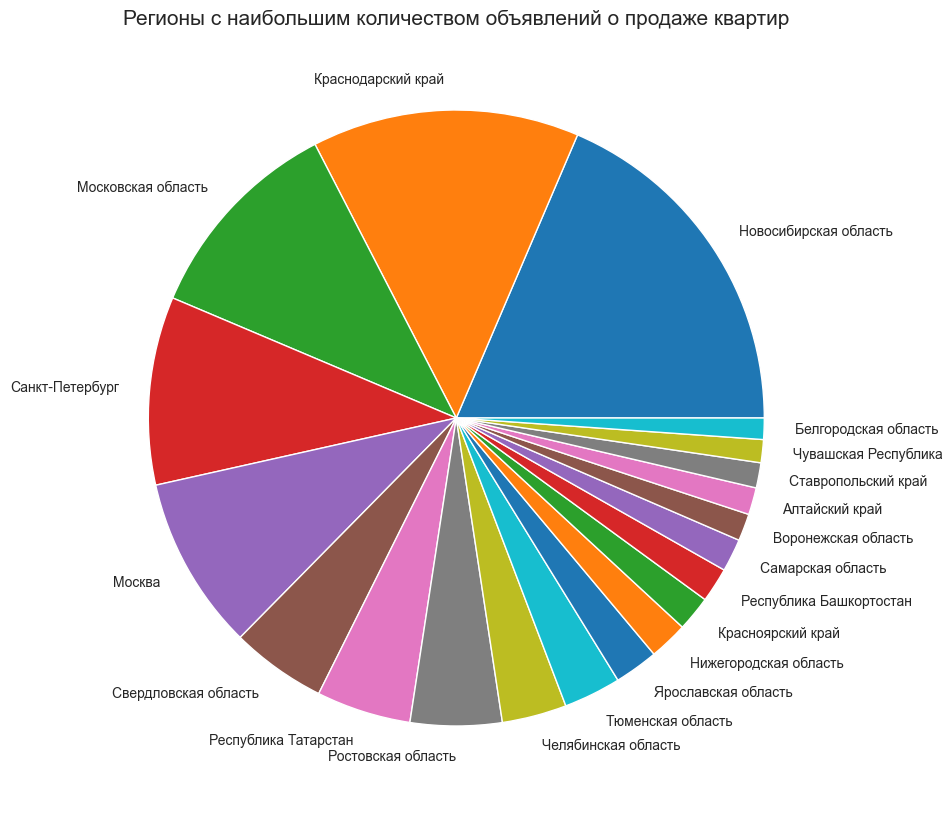

In [34]:
df['region_name'].value_counts().head(20).plot(kind='pie',stacked=True,figsize=(20,10))
plt.title("Регионы с наибольшим количеством объявлений о продаже квартир",fontsize=15)
plt.ylabel(' ')

Исследовательский анализ данных
Выявление для каждого из исследуемых регионов средней, максимальной, минимальной цены на квартиры

In [35]:
mean_price = df.groupby('region_name', as_index=False).agg(avg_price = ("price", "mean")).round(2)
mean_price

,region_name,avg_price
0,Алтайский край,2363926.690
1,Амурская область,4726634.750
2,Архангельская область,3963095.970
3,Астраханская область,3031426.820
4,Белгородская область,3281193.630
...,...,...
77,Челябинская область,2061298.190
78,Чеченская Республика,2818172.850
79,Чувашская Республика,2410674.320
80,Ямало-Ненецкий автономный округ,4001100.310


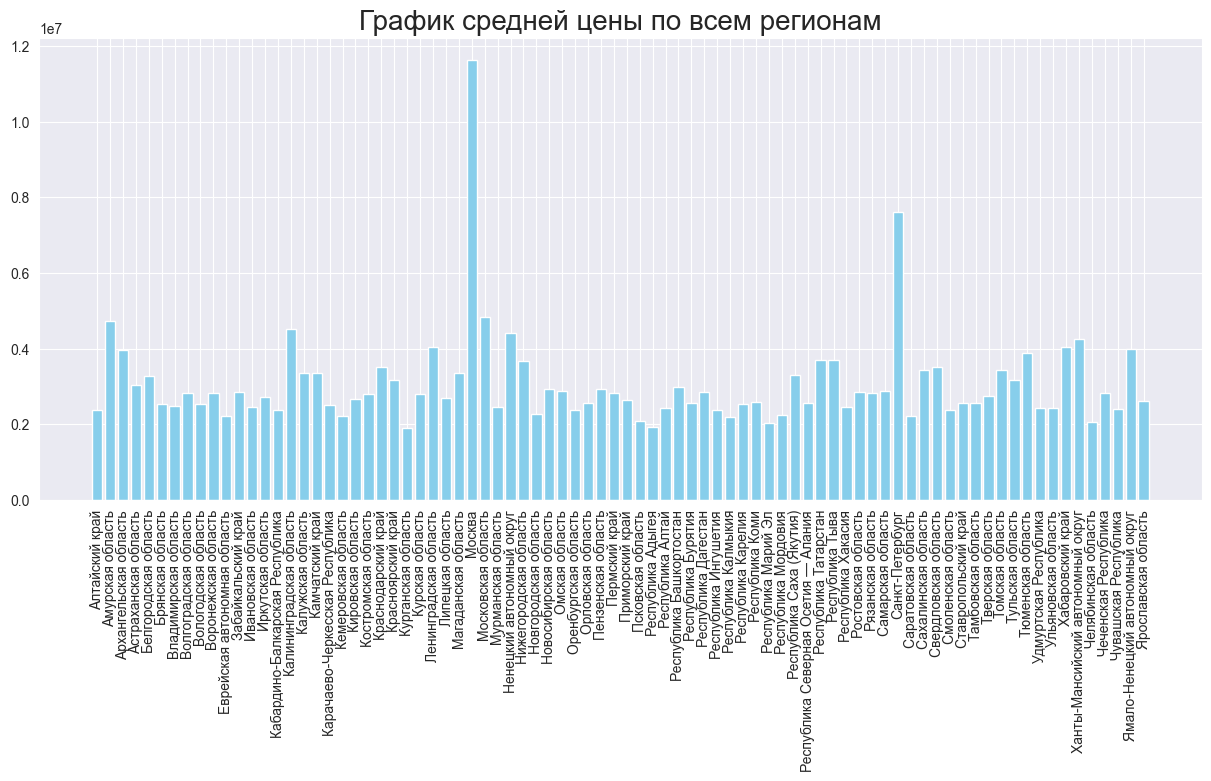

In [38]:
plt.figure(figsize=(15, 6))
plt.bar(x=mean_price['region_name'],height=mean_price['avg_price'], color='skyblue')
plt.title('График средней цены по всем регионам', fontsize=20)
plt.xticks(rotation=90)
plt.show()

In [39]:
max_price = df.groupby('region_name', as_index=False).agg(max_price = ("price", "max"))
max_price

,region_name,max_price
0,Алтайский край,21924000
1,Амурская область,22000000
2,Архангельская область,16800000
3,Астраханская область,12000000
4,Белгородская область,19000000
...,...,...
77,Челябинская область,31500000
78,Чеченская Республика,17000000
79,Чувашская Республика,23500000
80,Ямало-Ненецкий автономный округ,12500000


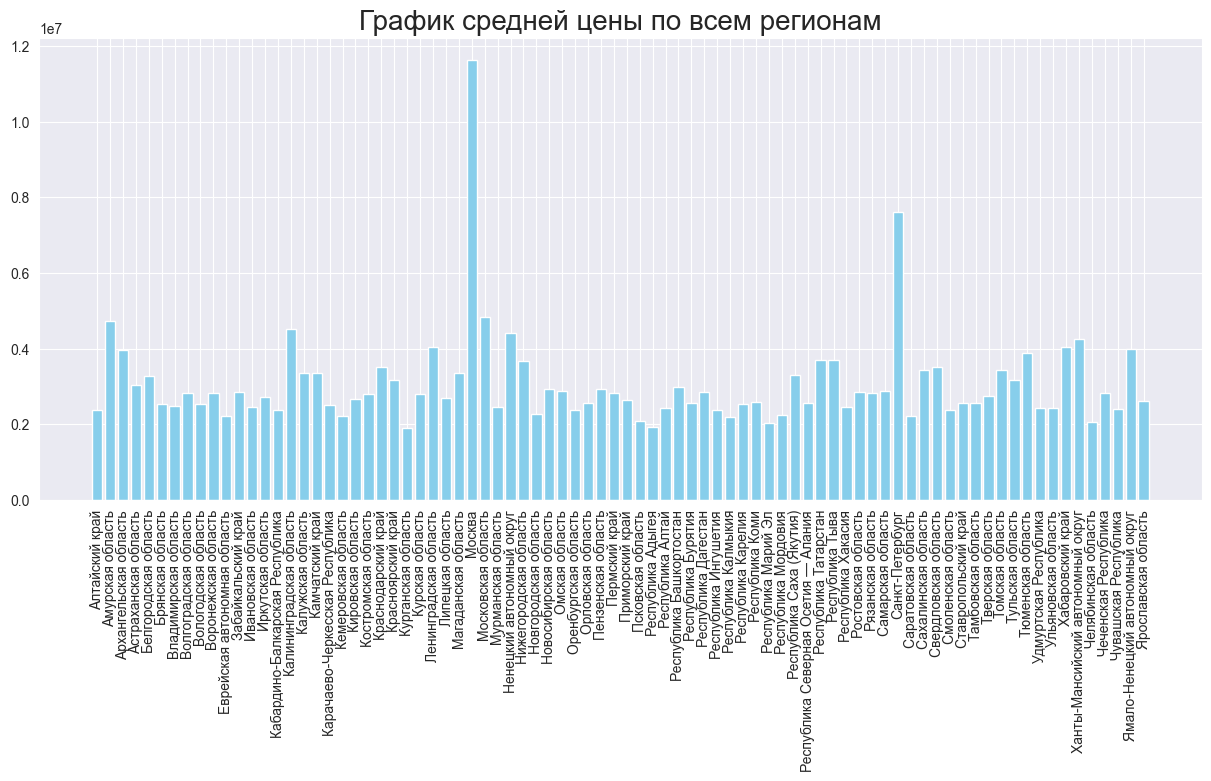

In [37]:
max_price = df.groupby('region_name', as_index=False).agg(max_price = ("price", "max"))
max_price

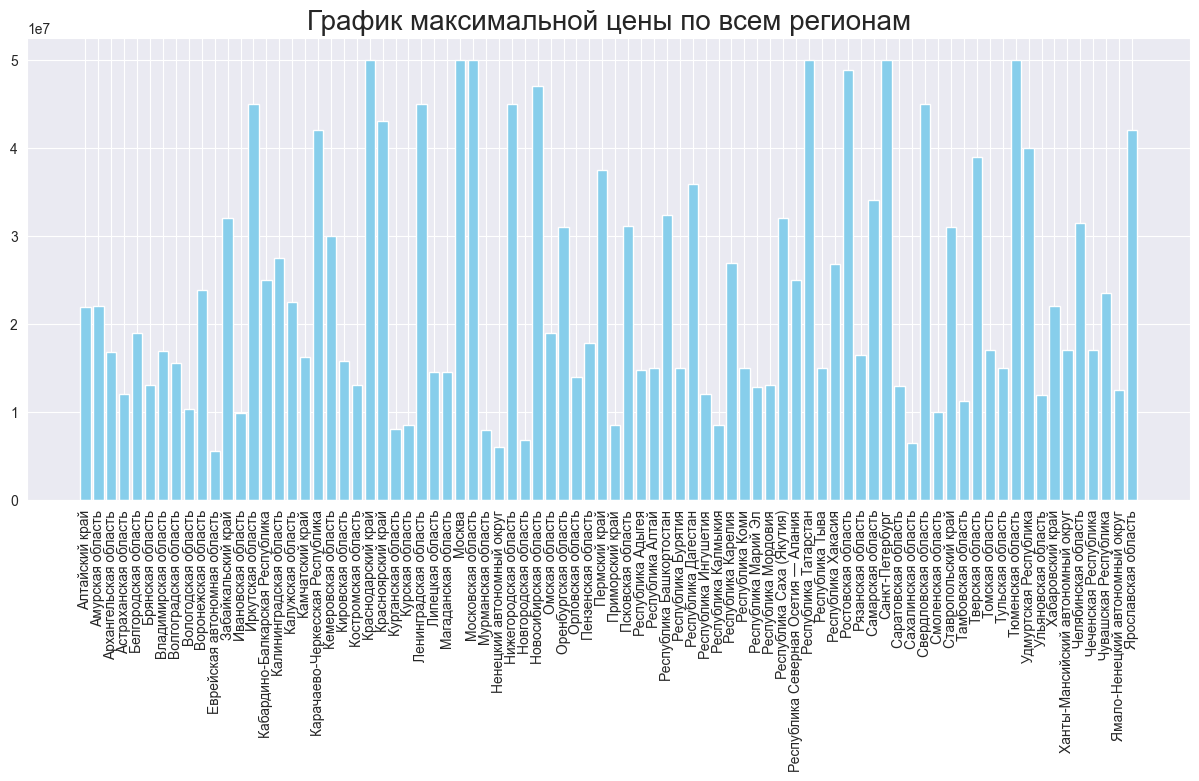

In [40]:
plt.figure(figsize=(15, 6))
plt.bar(x=max_price['region_name'],height=max_price['max_price'], color='skyblue')
plt.title('График максимальной цены по всем регионам', fontsize=20)
plt.xticks(rotation=90)
plt.show()

In [41]:
most_expensive = df.sort_values(by = 'price', ascending=False)
most_expensive[['region_name', 'price']].head(20).drop_duplicates()

,region_name,price
5427133,Санкт-Петербург,50000000
1230011,Москва,50000000
16056,Краснодарский край,50000000


In [42]:
cheapest = df.sort_values(by = 'price', ascending=True)
cheapest[['region_name', 'price']].head(10)

,region_name,price
4016302,Астраханская область,800000
5476950,Нижегородская область,800000
1643231,Самарская область,800000
3021449,Новосибирская область,800000
2277891,Челябинская область,800000
3602942,Республика Хакасия,800000
4016728,Тюменская область,800000
3726526,Ростовская область,800000
3727613,Красноярский край,800000
1644243,Ставропольский край,800000


In [43]:
df0 = df.copy()

df = df.drop(columns=['level_to_levels', 'area_to_rooms', 'month', 'region'])

#df['level_to_levels'] = df['level_to_levels'].map(lambda x: '%.4f' % x)
#df['area_to_rooms'] = df['area_to_rooms'].map(lambda x: '%.4f' % x)

df.head()

,price,geo_lat,geo_lon,building_type,level,levels,rooms,area,kitchen_area,object_type,year,region_name
0,6050000,59.806,30.376,1,8,10,3,82.600,10.800,1,2018,Санкт-Петербург
1,8650000,55.684,37.297,3,5,24,2,69.100,12.000,1,2018,Московская область
2,4000000,56.295,44.062,1,5,9,3,66.000,10.000,1,2018,Нижегородская область
4,5450000,55.919,37.985,3,13,14,2,60.000,10.000,1,2018,Московская область
5,3300000,55.908,37.726,1,4,5,1,32.000,6.000,1,2018,Московская область


Корреляция набора данных, выбор отдельного региона для исследования

In [48]:
df_nn = df[df.region_name == 'Ростовская область'].copy()
df_nn.sample(10)

,price,geo_lat,geo_lon,building_type,level,levels,rooms,area,kitchen_area,object_type,year,region_name
3107882,2150000,47.306,39.726,3,2,3,1,32.400,9.000,1,2020,Ростовская область
2959656,2800000,47.290,39.700,1,4,9,2,54.000,9.000,1,2019,Ростовская область
3625667,3600000,47.229,39.690,2,16,24,1,46.000,11.000,1,2020,Ростовская область
5473888,5190000,47.225,39.691,2,11,19,2,70.000,10.000,1,2021,Ростовская область
1132703,1990000,47.225,39.777,2,1,22,1,30.000,7.000,1,2019,Ростовская область
450037,2100000,47.300,39.744,3,7,10,1,35.000,10.000,1,2018,Ростовская область
2556699,2650000,47.239,39.801,3,5,10,1,42.000,12.000,1,2019,Ростовская область
1286735,4900000,47.236,39.599,1,10,17,3,71.000,21.000,1,2019,Ростовская область
2351408,2290000,47.236,39.599,1,7,17,1,40.000,9.400,1,2019,Ростовская область
579312,1980000,47.281,39.702,3,15,19,1,48.000,12.000,1,2018,Ростовская область


In [49]:
df_nn = df_nn.drop(columns=['region_name', 'levels'])

df_nn.shape

(201653, 10)

Матрица корреляции

In [50]:
df_nn.corr()

,price,geo_lat,geo_lon,building_type,level,rooms,area,kitchen_area,object_type,year
price,1.000,-0.161,-0.117,0.027,0.206,0.456,0.733,0.446,-0.003,0.112
geo_lat,-0.161,1.000,0.440,0.051,-0.112,0.085,0.004,-0.088,-0.073,0.025
geo_lon,-0.117,0.440,1.000,-0.037,-0.066,0.074,0.007,-0.069,-0.071,-0.012
building_type,0.027,0.051,-0.037,1.000,-0.068,-0.039,0.020,0.035,0.005,0.021
level,0.206,-0.112,-0.066,-0.068,1.000,-0.121,0.066,0.224,0.287,0.101
rooms,0.456,0.085,0.074,-0.039,-0.121,1.000,0.781,0.166,-0.088,0.019
area,0.733,0.004,0.007,0.020,0.066,0.781,1.000,0.442,0.021,0.046
kitchen_area,0.446,-0.088,-0.069,0.035,0.224,0.166,0.442,1.000,0.164,0.084
object_type,-0.003,-0.073,-0.071,0.005,0.287,-0.088,0.021,0.164,1.000,0.109
year,0.112,0.025,-0.012,0.021,0.101,0.019,0.046,0.084,0.109,1.000


In [51]:
mask = np.zeros_like(df_nn.corr())
triangle_indices = np.triu_indices_from(mask)
mask[triangle_indices] = True
mask

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

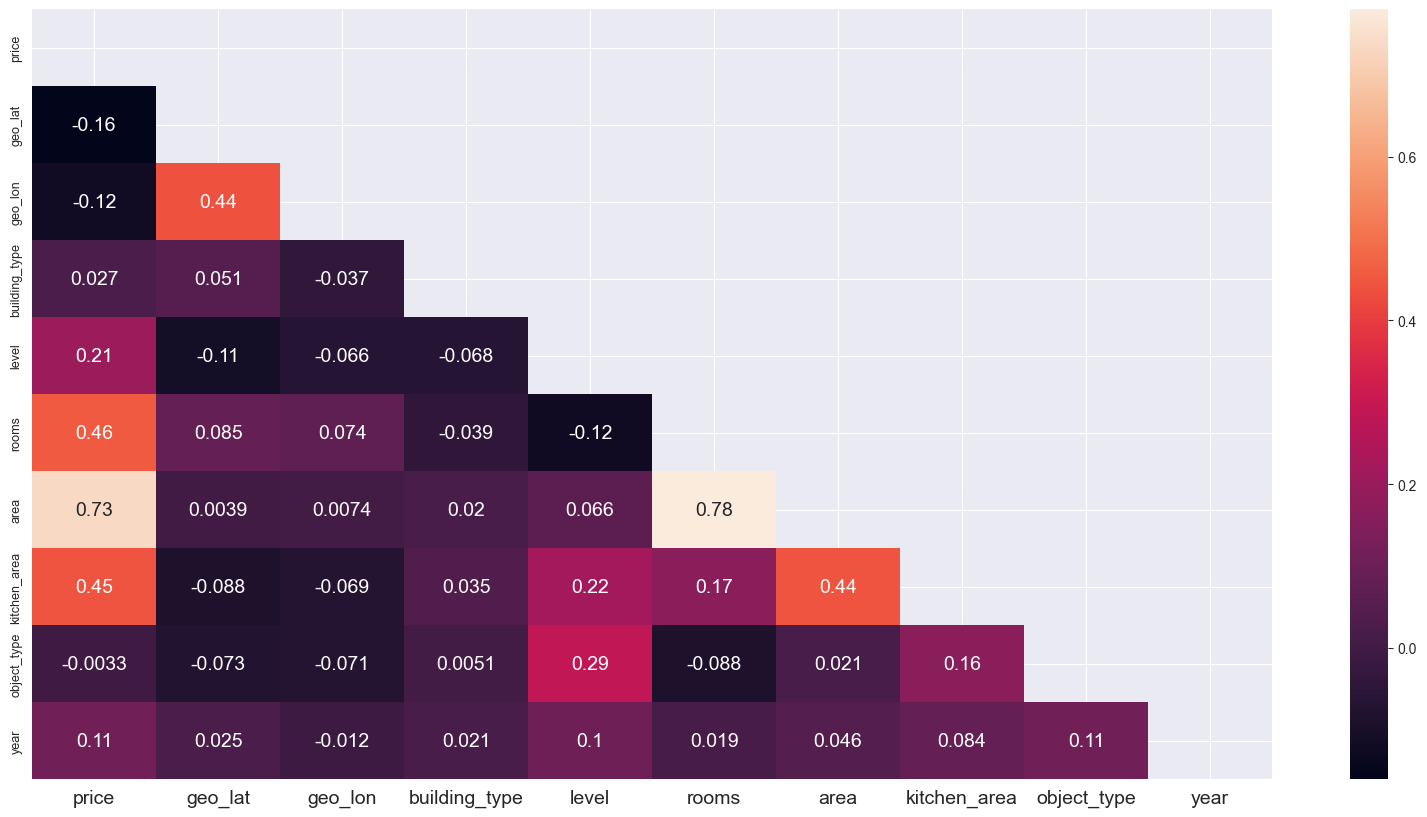

In [52]:
plt.figure(figsize=(20, 10))
sns.heatmap(df_nn.corr(), mask=mask, annot=True, annot_kws={'size':14})
sns.set_style('white')
plt.xticks(fontsize=14)
plt.yticks(fontsize=9)
plt.show()

График рассеивания

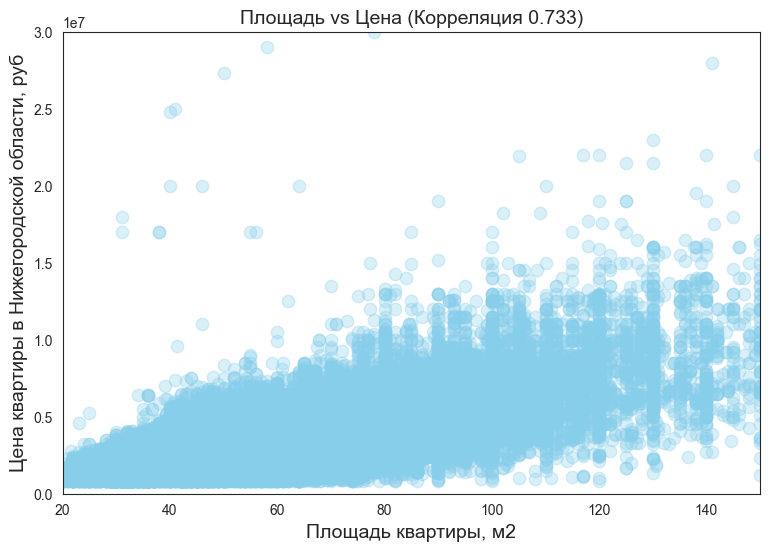

In [53]:
rm_tgt_corr = round(df_nn['area'].corr(df_nn['price']), 3)

plt.figure(figsize=(9, 6))
plt.scatter(x=df_nn['area'], y=df_nn['price'], alpha=0.3, s=80, color='skyblue')

plt.title(f'Площадь vs Цена (Корреляция {rm_tgt_corr})', fontsize=14)
plt.xlabel('Площадь квартиры, м2', fontsize=14)
plt.ylabel('Цена квартиры в Нижегородской области, руб', fontsize=14)
plt.xlim(20, 150)
plt.ylim(0, 30000000)
plt.show()

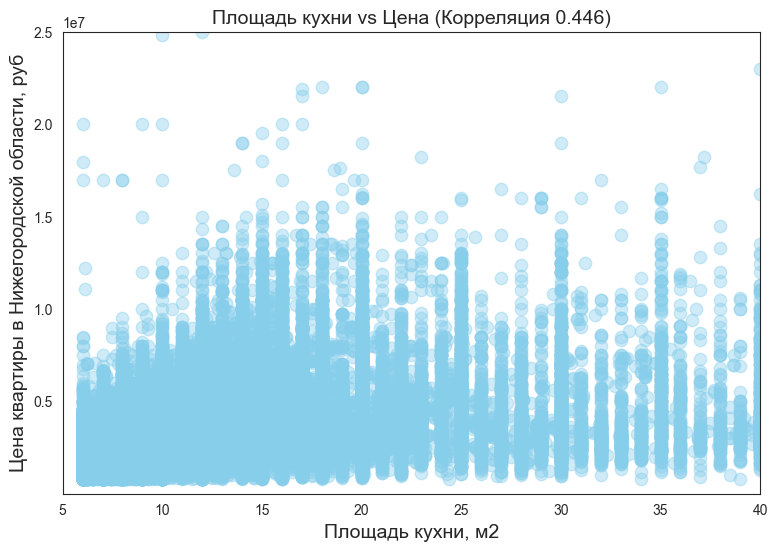

In [54]:
rm_tgt_corr = round(df_nn['kitchen_area'].corr(df_nn['price']), 3)

plt.figure(figsize=(9, 6))
plt.scatter(x=df_nn['kitchen_area'], y=df_nn['price'], alpha=0.4, s=80, color='skyblue')

plt.title(f'Площадь кухни vs Цена (Корреляция {rm_tgt_corr})', fontsize=14)
plt.xlabel('Площадь кухни, м2', fontsize=14)
plt.ylabel('Цена квартиры в Нижегородской области, руб', fontsize=14)
plt.xlim(5, 40)
plt.ylim(100, 25000000)
plt.show()

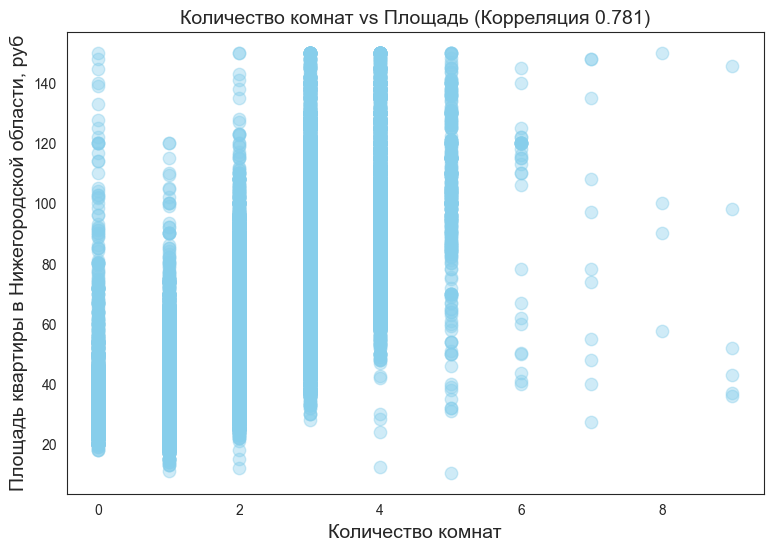

In [55]:
rm_tgt_corr = round(df_nn['rooms'].corr(df_nn['area']), 3)

plt.figure(figsize=(9, 6))
plt.scatter(x=df_nn['rooms'], y=df_nn['area'], alpha=0.4, s=80, color='skyblue')

plt.title(f'Количество комнат vs Площадь (Корреляция {rm_tgt_corr})', fontsize=14)
plt.xlabel('Количество комнат', fontsize=14)
plt.ylabel('Площадь квартиры в Нижегородской области, руб', fontsize=14)
plt.show()

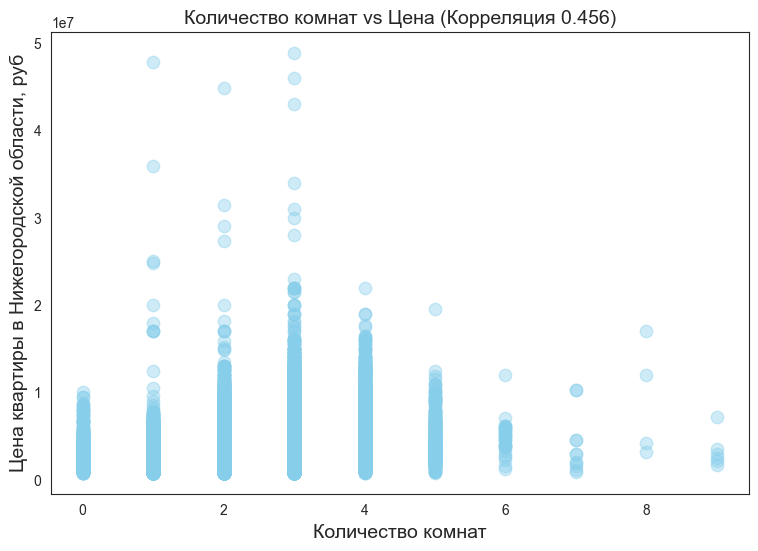

In [57]:
rm_tgt_corr = round(df_nn['rooms'].corr(df_nn['price']), 3)

plt.figure(figsize=(9, 6))
plt.scatter(x=df_nn['rooms'], y=df_nn['price'], alpha=0.4, s=80, color='skyblue')

plt.title(f'Количество комнат vs Цена (Корреляция {rm_tgt_corr})', fontsize=14)
plt.xlabel('Количество комнат', fontsize=14)
plt.ylabel('Цена квартиры в Нижегородской области, руб', fontsize=14)
plt.show()

In [ ]:
rm_tgt_corr = round(df_nn['kitchen_area'].corr(df_nn['area']), 3)

plt.figure(figsize=(9, 6))
plt.scatter(x=df_nn['kitchen_area'], y=df_nn['area'], alpha=0.4, s=80, color='skyblue')

plt.title(f'Площадь кухни vs Площадь всей квартиры (Корреляция {rm_tgt_corr})', fontsize=14)
plt.xlabel('Площадь кухни, м2', fontsize=14)
plt.ylabel('Площадь квартиры в Нижегородской области, руб', fontsize=14)
plt.show()

In [61]:
df_nn = df_nn.reset_index(drop=True)

In [ ]:
year = df_nn['year'].unique()
year

In [62]:
price = df_nn['price'].groupby(df_nn['year']).mean()
price

year
2018   2717687.471
2019   2754068.313
2020   2836061.404
2021   3382542.148
Name: price, dtype: float64

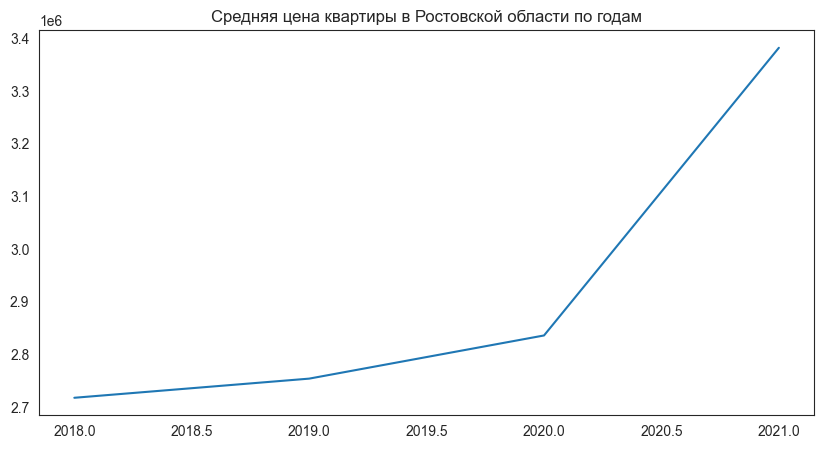

In [64]:
plt.figure(figsize=(10,5))  
plt.title('Средняя цена квартиры в Ростовской области по годам')
plt.plot(price)

array([2018, 2019, 2020, 2021], dtype=int32)